In [1]:
import os
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error
)

WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

X_FILE = os.path.join(WORK_DIR, "interim", "X_features.parquet")
Y_FILE = os.path.join(WORK_DIR, "interim", "y_target.parquet")
GROUP_FILE = os.path.join(WORK_DIR, "interim", "groups.parquet")
ROWID_FILE = os.path.join(WORK_DIR, "interim", "row_ids.parquet")

X = pd.read_parquet(X_FILE)
y = pd.read_parquet(Y_FILE)["T80_log1p"].copy()
groups = pd.read_parquet(GROUP_FILE)["Ref_DOI_number"].copy()
row_ids = pd.read_parquet(ROWID_FILE)["raw_row_id"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique DOI:", groups.nunique())

assert len(X) == len(y) == len(groups) == len(row_ids)

X shape: (1835, 77)
y shape: (1835,)
Unique DOI: 964


In [2]:
# ============================================================
# 06A_individual_device_regression.ipynb
# Individual-device regression with DOI-grouped validation
# Reviewer 1 — Comment 8
# ============================================================

import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [3]:
# ============================================================
# Evaluation function
# ============================================================

def evaluate_predictions(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "medae": median_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred))
    }

In [4]:
# ============================================================
# Regression models
# ============================================================

models = {
    "elasticnet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "hist_gbrt": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            random_state=42
        ))
    ])
}

print("Models:", list(models.keys()))

Models: ['elasticnet', 'random_forest', 'hist_gbrt']


In [5]:
# ============================================================
# PRIMARY ANALYSIS — 5-fold GroupKFold
# Individual devices retained; DOI used only for grouping
# ============================================================

gkf = GroupKFold(n_splits=5)

rows = []

for model_name, model in models.items():

    for fold, (train_idx, test_idx) in enumerate(
        gkf.split(X, y, groups=groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_predictions(y_test, y_pred)

        rows.append({
            "model": model_name,
            "fold": fold,
            **metrics,
            "n_train_devices": len(train_idx),
            "n_test_devices": len(test_idx),
            "train_DOI": groups.iloc[train_idx].nunique(),
            "test_DOI": groups.iloc[test_idx].nunique()
        })

gkf_scores = pd.DataFrame(rows)

gkf_summary = (
    gkf_scores
    .groupby("model")
    .agg(
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        medae_mean=("medae", "mean"),
        medae_std=("medae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        test_devices_mean=("n_test_devices", "mean"),
        test_DOI_mean=("test_DOI", "mean")
    )
    .reset_index()
    .sort_values("r2_mean", ascending=False)
)

display(gkf_summary)

,model,r2_mean,r2_std,mae_mean,mae_std,medae_mean,medae_std,rmse_mean,rmse_std,test_devices_mean,test_DOI_mean
0,elasticnet,0.093100,0.111507,1.398246,0.056550,1.143148,0.046705,1.792900,0.091295,367.0,192.8
2,random_forest,0.074265,0.107303,1.424727,0.047008,1.197888,0.046609,1.811258,0.072141,367.0,192.8
1,hist_gbrt,0.046143,0.136615,1.446462,0.083506,1.192964,0.078031,1.837043,0.108093,367.0,192.8


In [6]:
# ============================================================
# SECONDARY ANALYSIS — DOI-grouped GroupShuffleSplit
# ============================================================

gss = GroupShuffleSplit(
    n_splits=30,
    test_size=0.20,
    random_state=42
)

rows = []

for model_name, model in models.items():

    for split_id, (train_idx, test_idx) in enumerate(
        gss.split(X, y, groups=groups),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_predictions(y_test, y_pred)

        rows.append({
            "model": model_name,
            "split": split_id,
            **metrics,
            "n_test_devices": len(test_idx),
            "test_DOI": groups.iloc[test_idx].nunique()
        })

gss_scores = pd.DataFrame(rows)

gss_summary = (
    gss_scores
    .groupby("model")
    .agg(
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        medae_mean=("medae", "mean"),
        medae_std=("medae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        test_devices_mean=("n_test_devices", "mean"),
        test_DOI_mean=("test_DOI", "mean")
    )
    .reset_index()
    .sort_values("r2_mean", ascending=False)
)

display(gss_summary)

,model,r2_mean,r2_std,mae_mean,mae_std,medae_mean,medae_std,rmse_mean,rmse_std,test_devices_mean,test_DOI_mean
0,elasticnet,0.129450,0.061238,1.374910,0.079294,1.134027,0.084985,1.747302,0.093141,368.5,193.0
1,hist_gbrt,0.065870,0.074196,1.425362,0.077555,1.172321,0.086131,1.809597,0.098690,368.5,193.0
2,random_forest,0.053321,0.077299,1.440616,0.087766,1.177244,0.108939,1.821715,0.104746,368.5,193.0


In [7]:
# ============================================================
# CHRONOLOGICAL HOLDOUT — INDIVIDUAL DEVICES
# Train: publication year <= 2019
# Test : publication year >= 2020
# DOI aggregation is NOT used
# ============================================================

LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

labels_final = pd.read_parquet(LABEL_FILE)[
    ["raw_row_id", "publication_year"]
].copy()

# Map publication year to the same individual-device rows used in X
year_map = labels_final.set_index(
    "raw_row_id"
)["publication_year"]

publication_year = pd.to_numeric(
    row_ids.map(year_map),
    errors="coerce"
)

# Reset indices to guarantee alignment
X_chrono = X.reset_index(drop=True)
y_chrono = y.reset_index(drop=True)
groups_chrono = groups.reset_index(drop=True)
years_chrono = publication_year.reset_index(drop=True)

valid_mask = years_chrono.notna()

train_mask = valid_mask & (years_chrono <= 2019)
test_mask = valid_mask & (years_chrono >= 2020)

print("Chronological split — individual devices")
print("Train: publication year <= 2019")
print("Test : publication year >= 2020")

print("\nTrain devices:", int(train_mask.sum()))
print("Test devices :", int(test_mask.sum()))

print(
    "Train DOI:",
    groups_chrono.loc[train_mask].nunique()
)

print(
    "Test DOI:",
    groups_chrono.loc[test_mask].nunique()
)

# Check that no DOI occurs in both train and test
train_doi = set(
    groups_chrono.loc[train_mask].dropna()
)

test_doi = set(
    groups_chrono.loc[test_mask].dropna()
)

doi_overlap = train_doi.intersection(test_doi)

print("DOI overlap between train and test:", len(doi_overlap))

# ------------------------------------------------------------
# Fit and evaluate
# ------------------------------------------------------------

chrono_rows = []

for model_name, model in models.items():

    X_train = X_chrono.loc[train_mask]
    X_test = X_chrono.loc[test_mask]

    y_train = y_chrono.loc[train_mask]
    y_test = y_chrono.loc[test_mask]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_predictions(
        y_test,
        y_pred
    )

    chrono_rows.append({
        "model": model_name,
        **metrics,
        "n_train_devices": len(y_train),
        "n_test_devices": len(y_test),
        "train_DOI": groups_chrono.loc[train_mask].nunique(),
        "test_DOI": groups_chrono.loc[test_mask].nunique()
    })

chrono_summary = (
    pd.DataFrame(chrono_rows)
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
)

display(chrono_summary)

Chronological split — individual devices
Train: publication year <= 2019
Test : publication year >= 2020

Train devices: 1741
Test devices : 94
Train DOI: 917
Test DOI: 47
DOI overlap between train and test: 0


,model,r2,mae,medae,rmse,n_train_devices,n_test_devices,train_DOI,test_DOI
0,hist_gbrt,-0.184195,1.616865,1.446794,1.911040,1741,94,917,47
1,random_forest,-0.296546,1.721239,1.696776,1.999642,1741,94,917,47
2,elasticnet,-0.442115,1.714014,1.287262,2.108911,1741,94,917,47


Best GroupKFold model: elasticnet
Mean GroupKFold R²: 0.093 ± 0.112
Pooled OOF R²: 0.103
OOF devices: 1835

Chronological split:
Train devices: 1741
Test devices: 94
Train DOI: 917
Test DOI: 47
DOI overlap: 0

Best chronological model: hist_gbrt
Chronological R²: -0.184


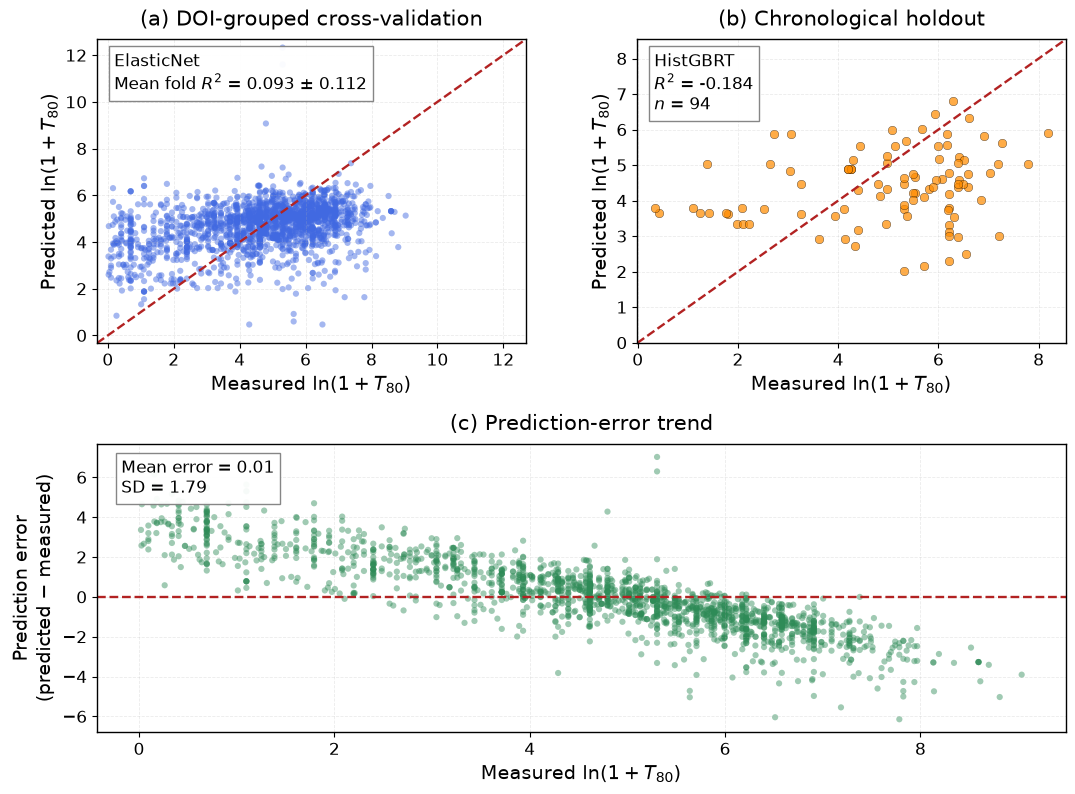


Saved Figure 2:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_individual_device_regression\Fig2_individual_regression_publication.png


In [14]:
# ============================================================
# FIGURE 2 — PUBLICATION-QUALITY INDIVIDUAL-DEVICE REGRESSION
#
# (a) DOI-grouped 5-fold out-of-fold predictions
# (b) Chronological holdout: <=2019 train, >=2020 test
# (c) Prediction-error trend
#
# No chrono_example variable is required
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score


# ============================================================
# 1. Output directory
# ============================================================

ARTIFACT_DIR = os.path.join(
    WORK_DIR,
    "artifacts",
    "06A_individual_device_regression"
)

os.makedirs(
    ARTIFACT_DIR,
    exist_ok=True
)


# ============================================================
# 2. Reset indices to guarantee alignment
# ============================================================

X_fig = X.reset_index(drop=True)
y_fig = y.reset_index(drop=True)
groups_fig = groups.reset_index(drop=True)
row_ids_fig = row_ids.reset_index(drop=True)


# ============================================================
# 3. BEST GROUPKFOLD MODEL
# ============================================================

best_group_model_name = (
    gkf_summary
    .sort_values("r2_mean", ascending=False)
    .iloc[0]["model"]
)

best_group_r2_mean = (
    gkf_summary
    .sort_values("r2_mean", ascending=False)
    .iloc[0]["r2_mean"]
)

best_group_r2_std = (
    gkf_summary
    .sort_values("r2_mean", ascending=False)
    .iloc[0]["r2_std"]
)

print("Best GroupKFold model:", best_group_model_name)

print(
    "Mean GroupKFold R²:",
    f"{best_group_r2_mean:.3f} ± {best_group_r2_std:.3f}"
)


# ============================================================
# 4. Generate 5-fold out-of-fold predictions
# ============================================================

gkf_fig = GroupKFold(
    n_splits=5
)

oof_pred = np.full(
    len(y_fig),
    np.nan
)

for fold, (train_idx, test_idx) in enumerate(
    gkf_fig.split(
        X_fig,
        y_fig,
        groups=groups_fig
    ),
    start=1
):

    fold_model = clone(
        models[best_group_model_name]
    )

    fold_model.fit(
        X_fig.iloc[train_idx],
        y_fig.iloc[train_idx]
    )

    oof_pred[test_idx] = fold_model.predict(
        X_fig.iloc[test_idx]
    )

assert np.isfinite(oof_pred).all()

y_oof = y_fig.to_numpy()

pooled_oof_r2 = r2_score(
    y_oof,
    oof_pred
)

oof_errors = (
    oof_pred - y_oof
)

print(
    "Pooled OOF R²:",
    f"{pooled_oof_r2:.3f}"
)

print(
    "OOF devices:",
    len(y_oof)
)


# ============================================================
# 5. RECONSTRUCT CHRONOLOGICAL HOLDOUT
# ============================================================

LABEL_FILE = os.path.join(
    WORK_DIR,
    "interim",
    "t80_labels.parquet"
)

labels_final = pd.read_parquet(
    LABEL_FILE
)[
    [
        "raw_row_id",
        "publication_year"
    ]
].copy()

year_map = (
    labels_final
    .drop_duplicates("raw_row_id")
    .set_index("raw_row_id")["publication_year"]
)

years_fig = pd.to_numeric(
    row_ids_fig.map(year_map),
    errors="coerce"
)

valid_year = (
    years_fig.notna()
)

train_mask = (
    valid_year
    & (years_fig <= 2019)
)

test_mask = (
    valid_year
    & (years_fig >= 2020)
)


# ============================================================
# 6. Verify chronological split
# ============================================================

print("\nChronological split:")
print(
    "Train devices:",
    int(train_mask.sum())
)

print(
    "Test devices:",
    int(test_mask.sum())
)

print(
    "Train DOI:",
    groups_fig.loc[
        train_mask
    ].nunique()
)

print(
    "Test DOI:",
    groups_fig.loc[
        test_mask
    ].nunique()
)

train_doi = set(
    groups_fig.loc[
        train_mask
    ].dropna()
)

test_doi = set(
    groups_fig.loc[
        test_mask
    ].dropna()
)

doi_overlap = (
    train_doi.intersection(
        test_doi
    )
)

print(
    "DOI overlap:",
    len(doi_overlap)
)


# ============================================================
# 7. Best chronological model
# ============================================================

best_chrono_model_name = (
    chrono_summary
    .sort_values("r2", ascending=False)
    .iloc[0]["model"]
)

chrono_model = clone(
    models[
        best_chrono_model_name
    ]
)

chrono_model.fit(
    X_fig.loc[train_mask],
    y_fig.loc[train_mask]
)

y_test_chrono = (
    y_fig.loc[
        test_mask
    ]
    .to_numpy()
)

y_pred_chrono = chrono_model.predict(
    X_fig.loc[
        test_mask
    ]
)

chrono_r2 = r2_score(
    y_test_chrono,
    y_pred_chrono
)

print(
    "\nBest chronological model:",
    best_chrono_model_name
)

print(
    "Chronological R²:",
    f"{chrono_r2:.3f}"
)


# ============================================================
# 8. PUBLICATION-QUALITY STYLE
# ============================================================

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.0
})


# ============================================================
# 9. Figure layout
#
# Top:
#    (a) grouped CV       (b) chronological
#
# Bottom:
#    (c) prediction error — full width
# ============================================================

fig = plt.figure(
    figsize=(12.5, 9.0)
)

gs = GridSpec(
    2,
    2,
    figure=fig,
    height_ratios=[
        1.0,
        0.95
    ],
    hspace=0.34,
    wspace=0.26
)

ax1 = fig.add_subplot(
    gs[0, 0]
)

ax2 = fig.add_subplot(
    gs[0, 1]
)

ax3 = fig.add_subplot(
    gs[1, :]
)


# ============================================================
# 10. PANEL (a)
# DOI-GROUPED CROSS-VALIDATION
# ============================================================

ax1.scatter(
    y_oof,
    oof_pred,
    s=20,
    alpha=0.48,
    color="royalblue",
    edgecolors="none"
)

lim_min = min(
    y_oof.min(),
    oof_pred.min()
)

lim_max = max(
    y_oof.max(),
    oof_pred.max()
)

pad = 0.35

ax1.plot(
    [
        lim_min - pad,
        lim_max + pad
    ],
    [
        lim_min - pad,
        lim_max + pad
    ],
    linestyle="--",
    linewidth=1.7,
    color="firebrick"
)

ax1.set_xlim(
    lim_min - pad,
    lim_max + pad
)

ax1.set_ylim(
    lim_min - pad,
    lim_max + pad
)

ax1.set_xlabel(
    r"Measured $\ln(1+T_{80})$"
)

ax1.set_ylabel(
    r"Predicted $\ln(1+T_{80})$"
)

ax1.set_title(
    "(a) DOI-grouped cross-validation",
    pad=10
)

ax1.text(
    0.04,
    0.96,
    (
        f"ElasticNet\n"
        f"Mean fold $R^2$ = "
        f"{best_group_r2_mean:.3f} ± "
        f"{best_group_r2_std:.3f}"
    ),
    transform=ax1.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

ax1.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)


# ============================================================
# 11. PANEL (b)
# CHRONOLOGICAL HOLDOUT
# ============================================================

ax2.scatter(
    y_test_chrono,
    y_pred_chrono,
    s=38,
    alpha=0.72,
    color="darkorange",
    edgecolor="black",
    linewidth=0.30
)

lim_min_c = min(
    y_test_chrono.min(),
    y_pred_chrono.min()
)

lim_max_c = max(
    y_test_chrono.max(),
    y_pred_chrono.max()
)

pad_c = 0.35

ax2.plot(
    [
        lim_min_c - pad_c,
        lim_max_c + pad_c
    ],
    [
        lim_min_c - pad_c,
        lim_max_c + pad_c
    ],
    linestyle="--",
    linewidth=1.7,
    color="firebrick"
)

ax2.set_xlim(
    lim_min_c - pad_c,
    lim_max_c + pad_c
)

ax2.set_ylim(
    lim_min_c - pad_c,
    lim_max_c + pad_c
)

ax2.set_xlabel(
    r"Measured $\ln(1+T_{80})$"
)

ax2.set_ylabel(
    r"Predicted $\ln(1+T_{80})$"
)

ax2.set_title(
    "(b) Chronological holdout",
    pad=10
)

ax2.text(
    0.04,
    0.96,
    (
        f"HistGBRT\n"
        f"$R^2$ = {chrono_r2:.3f}\n"
        f"$n$ = {len(y_test_chrono)}"
    ),
    transform=ax2.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

ax2.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)


# ============================================================
# 12. PANEL (c)
# PREDICTION-ERROR TREND
# ============================================================

ax3.scatter(
    y_oof,
    oof_errors,
    s=20,
    alpha=0.45,
    color="seagreen",
    edgecolors="none"
)

ax3.axhline(
    0,
    color="firebrick",
    linestyle="--",
    linewidth=1.7
)

ax3.set_xlabel(
    r"Measured $\ln(1+T_{80})$"
)

ax3.set_ylabel(
    "Prediction error\n(predicted − measured)"
)

ax3.set_title(
    "(c) Prediction-error trend",
    pad=10
)

ax3.text(
    0.025,
    0.95,
    (
        f"Mean error = "
        f"{np.mean(oof_errors):.2f}\n"
        f"SD = "
        f"{np.std(oof_errors):.2f}"
    ),
    transform=ax3.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

ax3.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.25
)


# ============================================================
# 13. SAVE
# ============================================================

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "Fig2_individual_regression_publication.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        ARTIFACT_DIR,
        "Fig2_individual_regression_publication.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved Figure 2:"
)

print(
    os.path.join(
        ARTIFACT_DIR,
        "Fig2_individual_regression_publication.png"
    )
)

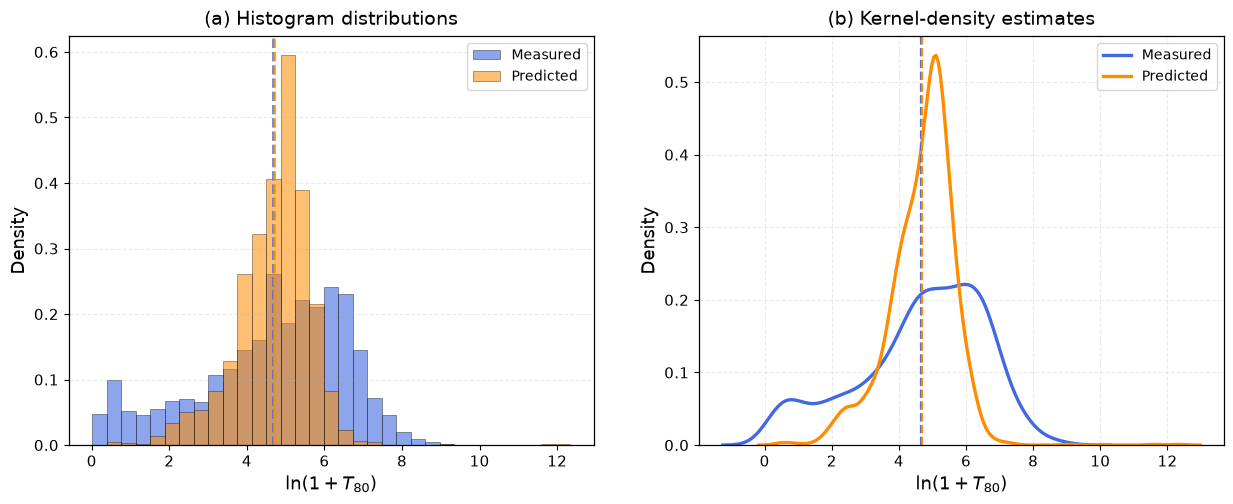

Saved Figure 3 in:
C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\06A_individual_device_regression


In [15]:
# ============================================================
# FIGURE 3 — DISTRIBUTION COMPARISON
# Improved resolution + larger publication layout
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
if "y_oof" not in globals():
    raise NameError("y_oof is not defined. Run the Figure 2 / OOF prediction cell first.")

if "oof_pred" not in globals():
    raise NameError("oof_pred is not defined. Run the Figure 2 / OOF prediction cell first.")

if "ARTIFACT_DIR" not in globals():
    ARTIFACT_DIR = os.path.join(
        WORK_DIR,
        "artifacts",
        "06A_individual_device_regression"
    )

os.makedirs(ARTIFACT_DIR, exist_ok=True)

y_true_plot = np.asarray(y_oof)
y_pred_plot = np.asarray(oof_pred)

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 0.9
})

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

xmin = min(y_true_plot.min(), y_pred_plot.min())
xmax = max(y_true_plot.max(), y_pred_plot.max())
bins = np.linspace(xmin, xmax, 34)

# ------------------------------------------------------------
# (a) Histogram comparison
# ------------------------------------------------------------
ax = axes[0]

ax.hist(
    y_true_plot,
    bins=bins,
    density=True,
    alpha=0.60,
    color="royalblue",
    edgecolor="black",
    linewidth=0.45,
    label="Measured"
)

ax.hist(
    y_pred_plot,
    bins=bins,
    density=True,
    alpha=0.55,
    color="darkorange",
    edgecolor="black",
    linewidth=0.45,
    label="Predicted"
)

ax.axvline(
    np.mean(y_true_plot),
    color="royalblue",
    linestyle="--",
    linewidth=1.8
)
ax.axvline(
    np.mean(y_pred_plot),
    color="darkorange",
    linestyle="--",
    linewidth=1.8
)

ax.set_title("(a) Histogram distributions", pad=8)
ax.set_xlabel(r"$\ln(1+T_{80})$")
ax.set_ylabel("Density")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.legend(frameon=True, fontsize=10)

# ------------------------------------------------------------
# (b) KDE comparison
# ------------------------------------------------------------
ax = axes[1]

sns.kdeplot(
    y_true_plot,
    ax=ax,
    color="royalblue",
    linewidth=2.4,
    fill=False,
    label="Measured"
)
sns.kdeplot(
    y_pred_plot,
    ax=ax,
    color="darkorange",
    linewidth=2.4,
    fill=False,
    label="Predicted"
)

ax.axvline(
    np.mean(y_true_plot),
    color="royalblue",
    linestyle="--",
    linewidth=1.6
)
ax.axvline(
    np.mean(y_pred_plot),
    color="darkorange",
    linestyle="--",
    linewidth=1.6
)

ax.set_title("(b) Kernel-density estimates", pad=8)
ax.set_xlabel(r"$\ln(1+T_{80})$")
ax.set_ylabel("Density")
ax.grid(True, linestyle="--", alpha=0.25)
ax.legend(frameon=True, fontsize=10)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
plt.tight_layout(w_pad=2.8)

plt.savefig(
    os.path.join(ARTIFACT_DIR, "Fig3_distribution_comparison_publication.png"),
    dpi=600,
    bbox_inches="tight"
)
plt.savefig(
    os.path.join(ARTIFACT_DIR, "Fig3_distribution_comparison_publication.pdf"),
    bbox_inches="tight"
)

plt.show()

print("Saved Figure 3 in:")
print(ARTIFACT_DIR)